In [1]:
#-----------AUSTRALIA WEATHER WEB SCRAPING PROJECT---------------

#Import the libraries needed
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re #----Website URL------------

url = "https://www.weather-forecast.com/countries/australia"

#--------Send Request to Website--------
headers = {
    "User-Agent": "JeshikaDataProject/1.0"
}
page = requests.get(url, headers=headers)

# Check whether the request was successful
print("Status code:", page.status_code)

#-----------Create beautifulsoup obj
soup = BeautifulSoup(page.text, "html.parser")
#print(soup.prettify())


Status code: 200


In [2]:
# ------------------------------------------------------------
# 5. EXTRACT CITY AND WEATHER INFORMATION
# ------------------------------------------------------------

# Create an empty list to store the scraped data
weather_data = []

# Find all city list items
city_items = soup.find_all("li", class_="b-list-table__item")


# Go through each city
for item in city_items:

    # Find the city name
    city_name = item.find(
        "span",
        class_="b-list-table__item-name"
    )

    # Find the weather/temperature information
    weather_value = item.find(
        "span",
        class_="b-list-table__item-value"
    )


    # Make sure both elements exist
    if city_name and weather_value:

        # Extract the city name
        city = city_name.get_text(strip=True)

        # Extract the weather information
        weather = weather_value.get_text(" ", strip=True)

        # Find the city URL
        city_link = city_name.find("a")

        if city_link:
            city_url = city_link.get("href")
        else:
            city_url = None


        # Store the information
        weather_data.append({
            "City": city,
            "Weather": weather,
            "URL": city_url
        })# Create Panda Data Frame


In [3]:

# Convert our list into a DataFrame
df = pd.DataFrame(weather_data) # Duplicate Handling
df = df.drop_duplicates(subset="City")# Reset DF index
df = df.reset_index(drop=True)
# Display Data
print("\nScraping completed!")
print("Number of cities:", len(df))

display(df)# Save the scraped data as a CSV file
df.to_csv(
    r"C:\Users\ACER\Desktop\DATAAN\Weather Web Scraping\australia_weather.csv",
    index=False
)


Scraping completed!
Number of cities: 100


,City,Weather,URL
0,Sydney,19,/locations/Sydney/forecasts/latest
1,Melbourne,12,/locations/Melbourne/forecasts/latest
2,Brisbane,17,/locations/Brisbane/forecasts/latest
3,Perth,20,/locations/Perth/forecasts/latest
4,Adelaide,12,/locations/Adelaide/forecasts/latest
...,...,...,...
95,Murray Bridge,13,/locations/Murray-Bridge/forecasts/latest
96,Echuca,13,/locations/Echuca/forecasts/latest
97,Devonport,11,/locations/Devonport/forecasts/latest
98,Glenmore Park,16,/locations/Glenmore-Park/forecasts/latest


In [7]:
# Basic Data Inspection

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Missing Values:
City       0
Weather    0
URL        0
dtype: int64

Duplicate Rows:
0


In [8]:
# Convert Weather column from object/text to numeric
df["Weather"] = pd.to_numeric(df["Weather"], errors="coerce")

# Check the data type
print(df["Weather"].dtype)

# Check the summary again
print("\nWeather Summary:")
print(df["Weather"].describe())

int64

Weather Summary:
count    100.000000
mean      15.550000
std        4.046135
min        8.000000
25%       12.000000
50%       16.500000
75%       18.250000
max       28.000000
Name: Weather, dtype: float64


In [9]:
# EDA STARTS 


# TOP 10 HOTTEST AND COLDEST CITIES

# Top 10 hottest cities from scraped data
hottest_cities = df.sort_values(
    by="Weather",
    ascending=False
).head(10)

print("TOP 10 HOTTEST CITIES")
display(hottest_cities[["City", "Weather"]])


# Top 10 coldest cities
coldest_cities = df.sort_values(
    by="Weather",
    ascending=True
).head(10)

print("TOP 10 COLDEST CITIES")
display(coldest_cities[["City", "Weather"]])


TOP 10 HOTTEST CITIES


,City,Weather
17,Darwin,28
66,Palmerston,28
73,Mount Isa,26
59,Geraldton,21
60,Maroubra,20
69,Canning Vale,20
62,Mosman,20
63,Randwick,20
50,Kalgoorlie-Boulder,20
3,Perth,20


TOP 10 COLDEST CITIES


,City,Weather
22,Ballarat,8
6,Canberra,9
29,Adelaide Hills,9
12,Hobart,9
35,Queanbeyan,9
68,Ferntree Gully,9
84,Goulburn,9
20,Launceston,10
21,Bendigo,10
88,Gawler,11


In [13]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [14]:
import matplotlib.pyplot as plt


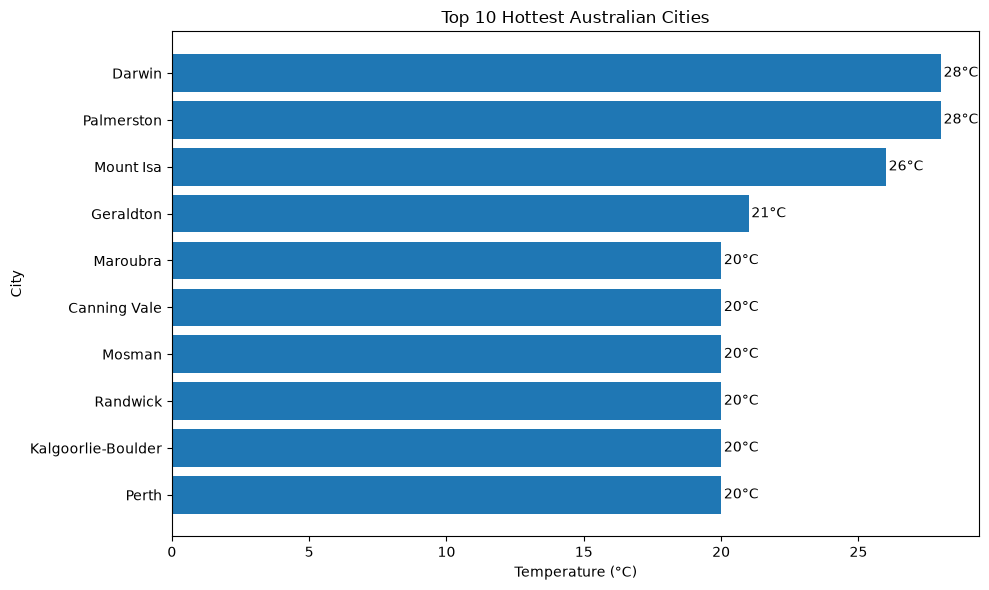

In [16]:

# Visualization of hottest cities 

plt.figure(figsize=(10, 6))

plt.barh(
    hottest_cities["City"][::-1],
    hottest_cities["Weather"][::-1]
)

plt.title("Top 10 Hottest Australian Cities")
plt.xlabel("Temperature (°C)")
plt.ylabel("City")

# Add temperature labels
for i, temp in enumerate(hottest_cities["Weather"][::-1]):
    plt.text(temp + 0.1, i, f"{temp}°C", va="center")

plt.tight_layout()
plt.show()

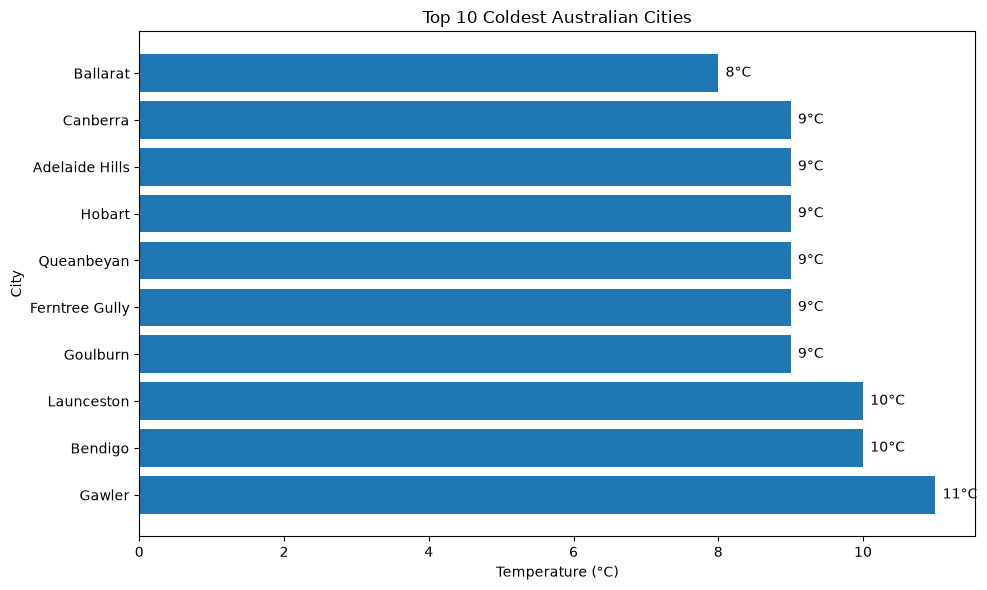

In [18]:
# Visualization of coldest cities 

plt.figure(figsize=(10, 6))

plt.barh(
    coldest_cities["City"][::-1],
    coldest_cities["Weather"][::-1]
)

plt.title("Top 10 Coldest Australian Cities")
plt.xlabel("Temperature (°C)")
plt.ylabel("City")

# Add temperature labels
for i, temp in enumerate(coldest_cities["Weather"][::-1]):
    plt.text(temp + 0.1, i, f"{temp}°C", va="center")

plt.tight_layout()
plt.show()


In [20]:
#-------- TEMPERATURE CATEGORIES-------------

def temperature_category(temp):
    if temp <= 12:
        return "10–12°C"
    elif temp <= 15:
        return "13–15°C"
    elif temp <= 18:
        return "16–18°C"
    else:
        return "19°C+"

df["Temperature_Category"] = df["Weather"].apply(
    temperature_category
)

display(df[["City", "Weather", "Temperature_Category"]])

,City,Weather,Temperature_Category
0,Sydney,19,19°C+
1,Melbourne,12,10–12°C
2,Brisbane,17,16–18°C
3,Perth,20,19°C+
4,Adelaide,12,10–12°C
...,...,...,...
95,Murray Bridge,13,13–15°C
96,Echuca,13,13–15°C
97,Devonport,11,10–12°C
98,Glenmore Park,16,16–18°C


In [22]:
# -----------TEMPERATURE CATEGORY DISTRIBUTION-----------

category_counts = df["Temperature_Category"].value_counts()

print("Cities by Temperature Category:")
display(category_counts)

Cities by Temperature Category:


Temperature_Category
16–18°C    31
10–12°C    30
19°C+      25
13–15°C    14
Name: count, dtype: int64

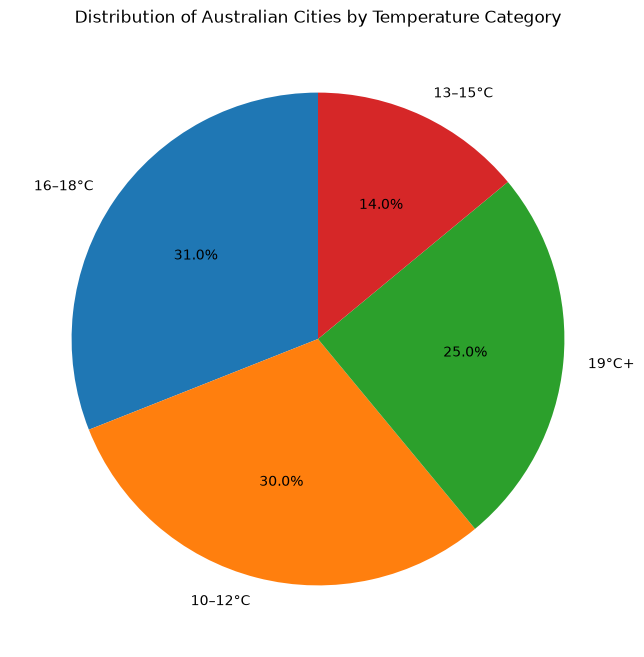

In [23]:
# -------VISUALIZATION: TEMPERATURE CATEGORY DISTRIBUTION--------------

plt.figure(figsize=(8, 8))

plt.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Australian Cities by Temperature Category")

plt.show()

In [ ]:
# Here from the visualization, our key insight is that, Most of the cities fall within the 16-18 degree temperature category
# Meanwhile, 25% of cities recorded temperature of 19 degree or higher.


# THIS IS AS PER DATA SCRAPPED WHILE MAKING THIS PROJECT 